In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from stock_forecasting.utils import Cfg
from stock_forecasting.datasets import StockDataset
from stock_forecasting.models.baseline import BaselineRNN, BaselineLSTM, BaselineGRU, BaselineCNN1D
from stock_forecasting.utils.training import train_model
from stock_forecasting.utils.evaluation import evaluate_model

np.random.seed(Cfg.SEED)
torch.manual_seed(Cfg.SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

plt.style.use("Solarize_Light2")

In [3]:
TICKER = "VCB"

train_set = StockDataset(ticker=TICKER, mode="train")
train_loader = DataLoader(train_set, batch_size=Cfg.BATCH_SIZE, shuffle=False)
train_loader_shuffled = DataLoader(train_set, batch_size=Cfg.BATCH_SIZE, shuffle=True)

val_set = StockDataset(ticker=TICKER, mode="val")
val_loader = DataLoader(val_set, batch_size=Cfg.BATCH_SIZE, shuffle=False)

test_set = StockDataset(ticker=TICKER, mode="test")
test_loader = DataLoader(test_set, batch_size=Cfg.BATCH_SIZE, shuffle=False)

              Baseline RNN              
----------------------------------------
[20/200] Train Loss = 0.7532 | Val Loss = 4.9688
[40/200] Train Loss = 0.5732 | Val Loss = 1.0260
[60/200] Train Loss = 0.4480 | Val Loss = 0.9778
[80/200] Train Loss = 0.4945 | Val Loss = 1.1993
[100/200] Train Loss = 0.4472 | Val Loss = 1.8243
[120/200] Train Loss = 0.3654 | Val Loss = 0.5581
[140/200] Train Loss = 0.4023 | Val Loss = 1.5608
[160/200] Train Loss = 0.4511 | Val Loss = 0.6639
[180/200] Train Loss = 0.3912 | Val Loss = 0.4092
[200/200] Train Loss = 0.3926 | Val Loss = 0.4283
MAE = 1.6769
MASE (%) = 584.2850
R2 = -0.3705
Dir Accuracy = 0.4450


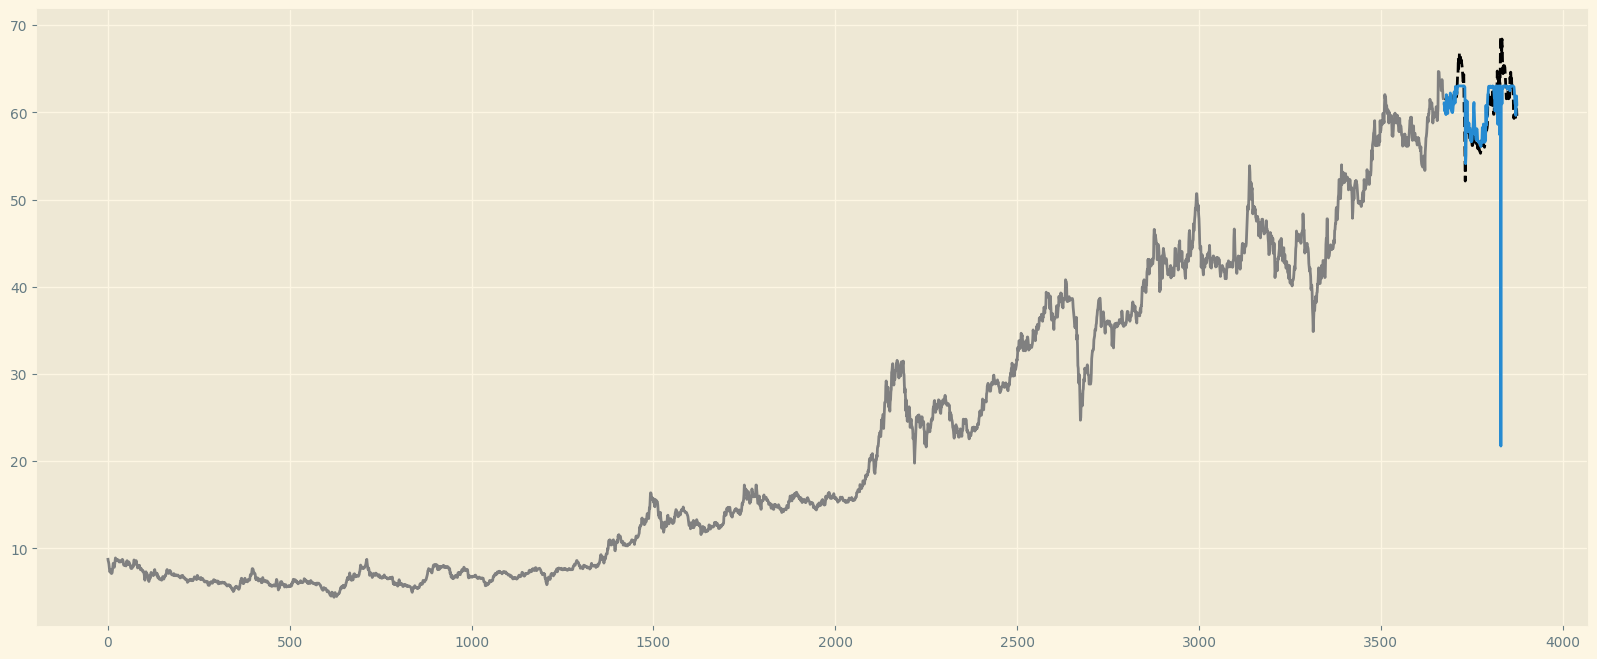

            Baseline BiLSTM             
----------------------------------------
[20/200] Train Loss = 0.6274 | Val Loss = 1.0312
[40/200] Train Loss = 0.4478 | Val Loss = 0.8473
[60/200] Train Loss = 0.4542 | Val Loss = 0.4077
[80/200] Train Loss = 0.4184 | Val Loss = 0.4113
[100/200] Train Loss = 0.3831 | Val Loss = 0.3748
[120/200] Train Loss = 0.3528 | Val Loss = 0.4433
[140/200] Train Loss = 0.3471 | Val Loss = 0.7440
[160/200] Train Loss = 0.3624 | Val Loss = 0.4229
[180/200] Train Loss = 0.3279 | Val Loss = 0.4351
[200/200] Train Loss = 0.3656 | Val Loss = 0.3824
MAE = 1.2965
MASE (%) = 451.7600
R2 = 0.6619
Dir Accuracy = 0.4550


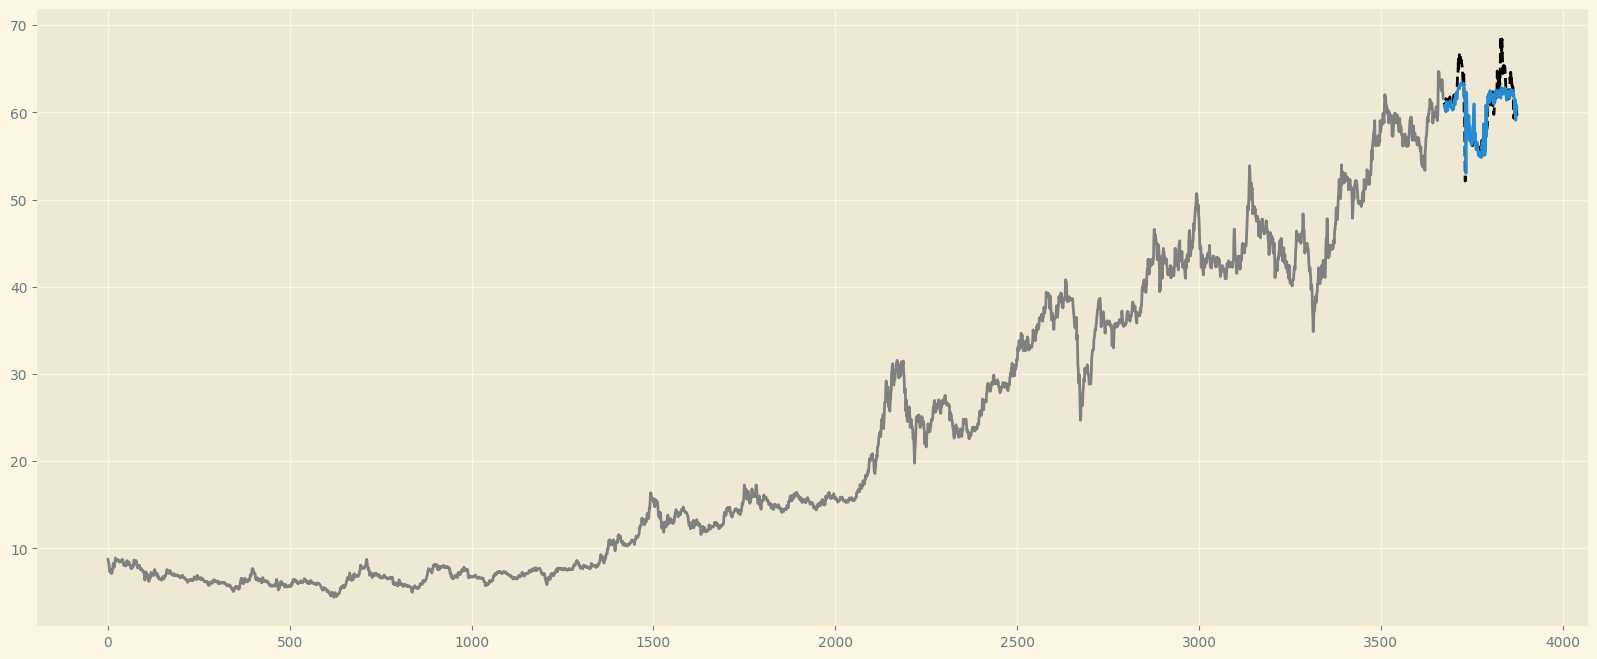

             Baseline BiGRU             
----------------------------------------
[20/200] Train Loss = 0.6346 | Val Loss = 1.0436
[40/200] Train Loss = 0.5311 | Val Loss = 0.4910
[60/200] Train Loss = 0.4444 | Val Loss = 0.6897
[80/200] Train Loss = 0.3720 | Val Loss = 0.3276
[100/200] Train Loss = 0.3572 | Val Loss = 0.5318
[120/200] Train Loss = 0.3294 | Val Loss = 0.3759
[140/200] Train Loss = 0.3478 | Val Loss = 0.3259
[160/200] Train Loss = 0.3299 | Val Loss = 0.2901
[180/200] Train Loss = 0.3271 | Val Loss = 0.6813
[200/200] Train Loss = 0.2993 | Val Loss = 0.4507
MAE = 1.2390
MASE (%) = 431.7078
R2 = 0.6659
Dir Accuracy = 0.4700


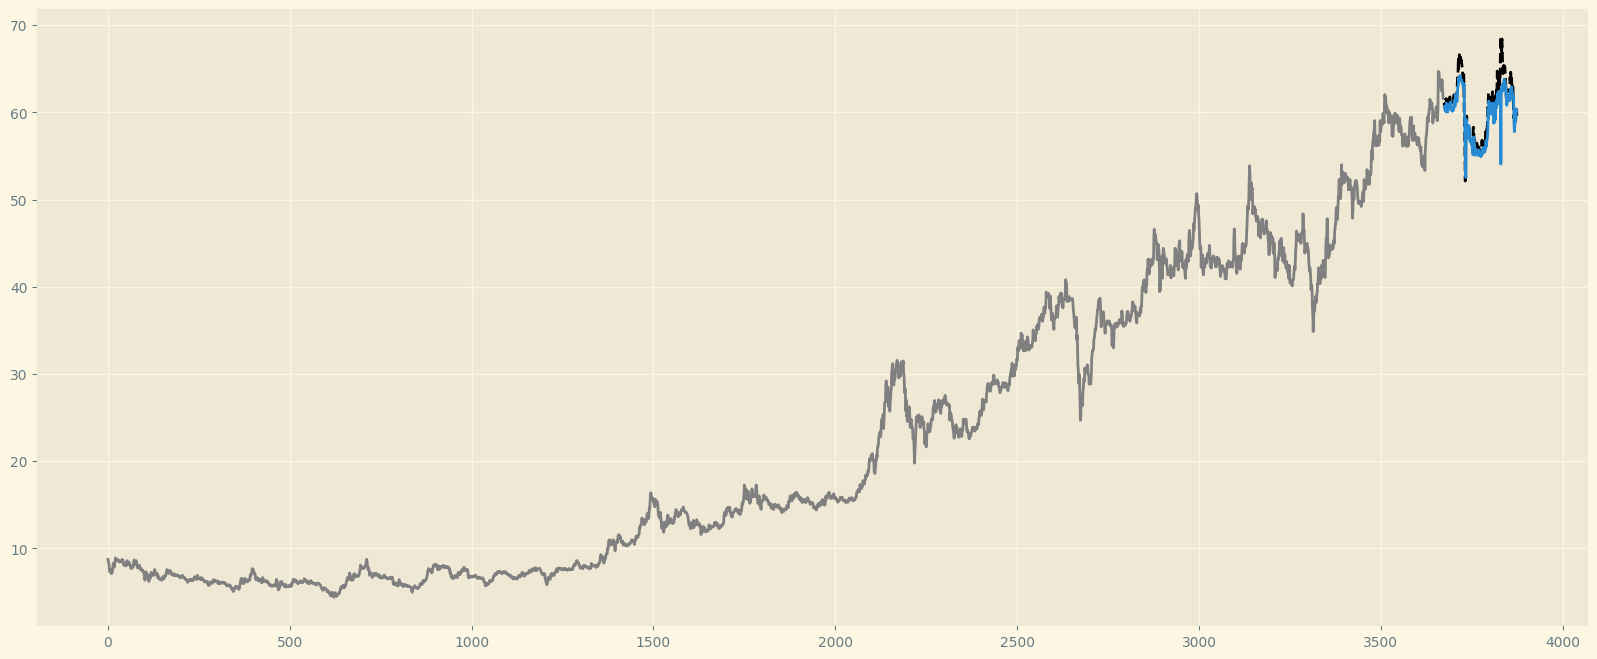

           Baseline CNN (1D)            
----------------------------------------


/home/muffin/University/Undergrad-Research/stock_forecasting/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/muffin/University/Undergrad-Research/stock_forecasting/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([25])) that is different to the input size (torch.Size([25, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/muffin/University/Undergrad-Research/stock_forecasting/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([12])) that is different to

[20/200] Train Loss = 284.7858 | Val Loss = 1306.6328
[40/200] Train Loss = 285.0928 | Val Loss = 1462.0175
[60/200] Train Loss = 284.7082 | Val Loss = 1338.0402
[80/200] Train Loss = 284.3846 | Val Loss = 1283.3165
[100/200] Train Loss = 284.3044 | Val Loss = 1435.9839
[120/200] Train Loss = 284.3600 | Val Loss = 1535.4114
[140/200] Train Loss = 284.6602 | Val Loss = 1449.8126
[160/200] Train Loss = 284.6894 | Val Loss = 1311.7878
[180/200] Train Loss = 284.2822 | Val Loss = 1379.9229
[200/200] Train Loss = 284.4040 | Val Loss = 1298.9761
MAE = 34.7317
MASE (%) = 12101.9189
R2 = -111.6575
Dir Accuracy = 0.4200


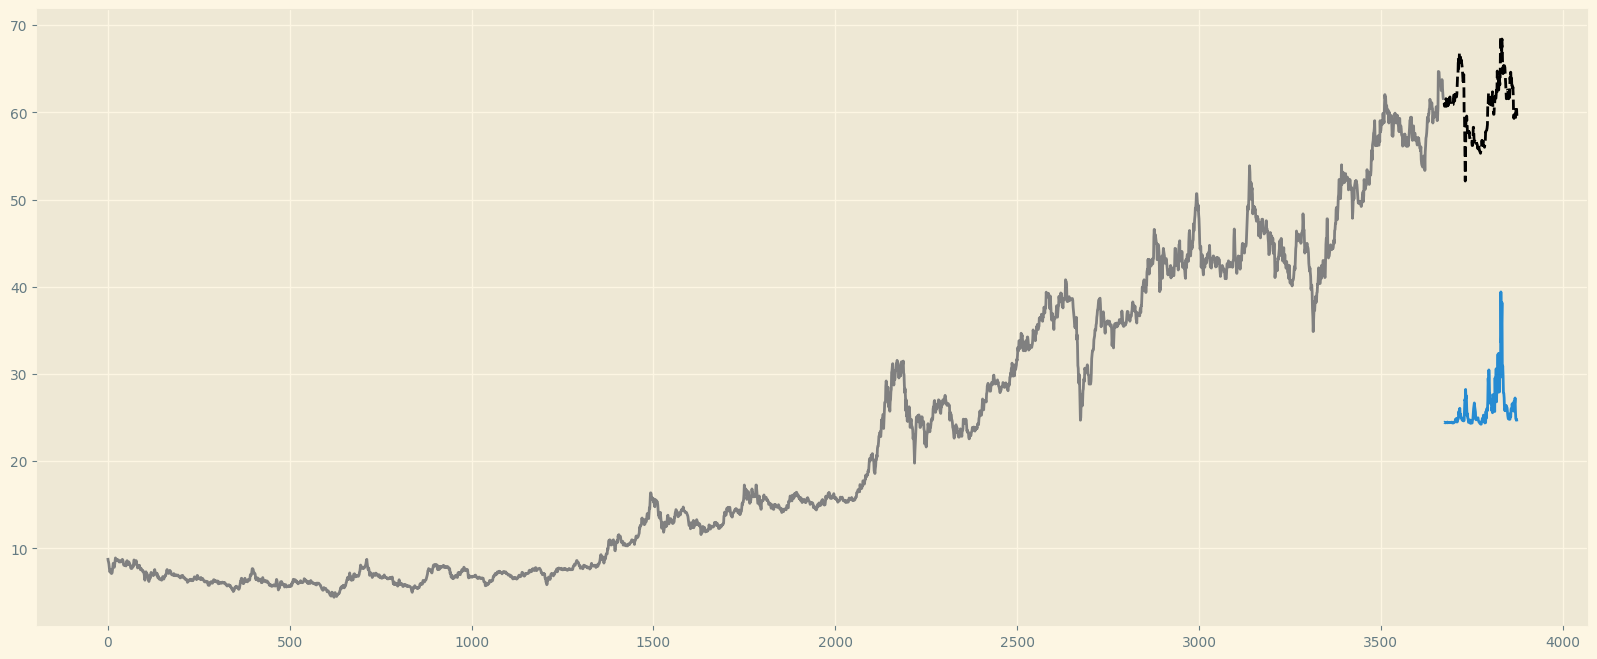

In [19]:
models = {
  "Baseline RNN": BaselineRNN(input_size=Cfg.SLIDING_WINDOW_SIZE, output_size=1, dropout=0.2),
  "Baseline BiLSTM": BaselineLSTM(input_size=Cfg.SLIDING_WINDOW_SIZE, output_size=1, dropout=0.2),
  "Baseline BiGRU": BaselineGRU(input_size=Cfg.SLIDING_WINDOW_SIZE, output_size=1, dropout=0.2),
  "Baseline CNN (1D)": BaselineCNN1D(input_size=Cfg.SLIDING_WINDOW_SIZE, output_size=1),
}

criterion = nn.MSELoss()

print_epoch = 20

for name, model in models.items():
  print(f"{name:^40}\n{'-' * 40}")
    
  optimizer = optim.Adam(model.parameters(), lr=1e-3)

  train_model(
    train_loader=train_loader_shuffled,
    val_loader=val_loader,
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    epochs=Cfg.NUM_EPOCHS,
    on_each_epoch=lambda epoch, train_loss, val_loss: print(
      f"[{epoch + 1}/{Cfg.NUM_EPOCHS}] Train Loss = {train_loss:>4.4f} | Val Loss = {val_loss:>4.4f}"
    ) if epoch % print_epoch == print_epoch - 1 else None,
    device=device,
  )

  metrics, y_true, y_hat, y_train = evaluate_model(
    model=model,
    test_loader=test_loader,
    train_loader=train_loader,
    device=device,
  )

  for metric, value in metrics.items():
    print(f"{metric} = {value:>4.4f}")

  plt.figure(figsize=(20, 8))

  X_range = range(len(y_train) + 1, len(y_train) + len(y_true) + 1)

  plt.plot(y_train, color="gray")
  plt.plot(X_range, y_true, color="black", linestyle="dashed")
  plt.plot(X_range, y_hat)

  plt.show()